In [53]:
!pip uninstall -y torchao
!pip install -q -U transformers accelerate peft evaluate sentencepiece protobuf scikit-learn datasets tqdm

In [54]:
import torch

print("CUDA var mı:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok.")

CUDA var mı: True
GPU: Tesla T4


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [57]:
import os

search_root = "/content/drive/MyDrive/turkish-news-classification"

for root, dirs, files in os.walk(search_root):
    if "interpress_prompt_sample_dataset" in dirs:
        print("Bulundu:", os.path.join(root, "interpress_prompt_sample_dataset"))

Bulundu: /content/drive/MyDrive/turkish-news-classification/notebooks/data/processed/interpress_prompt_sample_dataset


In [58]:
from pathlib import Path
from datasets import load_from_disk

DATASET_PATH = Path("/content/drive/MyDrive/turkish-news-classification/notebooks/data/processed/interpress_prompt_sample_dataset")

dataset = load_from_disk(str(DATASET_PATH))
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
})

In [59]:
print(dataset)

print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

print(dataset["train"][0].keys())
print(dataset["train"][0]["prompt"][:500])
print("Cevap:", dataset["train"][0]["answer"])

DatasetDict({
    train: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
})
Train: 8500
Validation: 1700
Test: 1700
dict_keys(['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'])
Görev: Aşağıdaki Türkçe haberin kategorisini belirle.
Sadece verilen kategorilerden birini yaz.

Kategoriler: aktuel, bilisim, egitim, ekonomi, gida, iletisim, kultursanat, magazin, saglik, savunma, seyahat, siyasi, spor, teknoloji, ticaret, turizm, yasam

Başlık: MANCHESTER'DA YOLLAR BOYANDI
Haber: Manchester da yollar boyandı Premier Lig in son haftasında QPR yi yenerek 44 yıl 

In [60]:
import torch

print("CUDA var mı:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok.")

CUDA var mı: True
GPU: Tesla T4


In [61]:
import os
import json
import torch
import numpy as np
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [62]:
PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")

RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "smollm2_lora_sample_fixed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

Output dir: /content/drive/MyDrive/turkish-news-classification/results/smollm2_lora_sample_fixed


In [63]:
MODEL_NAME = "HuggingFaceTB/SmolLM2-360M"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [64]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [65]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    bias="none"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 8,683,520 || all params: 370,504,640 || trainable%: 2.3437


In [66]:
MAX_LENGTH = 1024

def tokenize_function(example):
    prompt = example["prompt"]
    answer = " " + example["answer"] + tokenizer.eos_token

    answer_tokens = tokenizer(
        answer,
        add_special_tokens=False
    )

    max_prompt_length = MAX_LENGTH - len(answer_tokens["input_ids"])

    if max_prompt_length < 1:
        max_prompt_length = MAX_LENGTH - 10

    prompt_tokens = tokenizer(
        prompt,
        truncation=True,
        max_length=max_prompt_length,
        padding=False,
        add_special_tokens=False
    )

    input_ids = prompt_tokens["input_ids"] + answer_tokens["input_ids"]
    attention_mask = [1] * len(input_ids)

    labels = [-100] * len(prompt_tokens["input_ids"]) + answer_tokens["input_ids"]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [67]:
tokenized_dataset = dataset.map(
    tokenize_function,
    remove_columns=dataset["train"].column_names
)

tokenized_dataset

Map:   0%|          | 0/8500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1700
    })
})

In [68]:
def count_supervised_tokens(example):
    return sum(1 for x in example["labels"] if x != -100)

train_supervised = [
    count_supervised_tokens(tokenized_dataset["train"][i])
    for i in range(len(tokenized_dataset["train"]))
]

val_supervised = [
    count_supervised_tokens(tokenized_dataset["validation"][i])
    for i in range(len(tokenized_dataset["validation"]))
]

print("Train min supervised tokens:", min(train_supervised))
print("Validation min supervised tokens:", min(val_supervised))

print("Train sıfır supervised:", sum(1 for x in train_supervised if x == 0))
print("Validation sıfır supervised:", sum(1 for x in val_supervised if x == 0))

Train min supervised tokens: 2
Validation min supervised tokens: 2
Train sıfır supervised: 0
Validation sıfır supervised: 0


In [69]:
print(tokenized_dataset["train"][0].keys())
print("Input length:", len(tokenized_dataset["train"][0]["input_ids"]))
print("Label length:", len(tokenized_dataset["train"][0]["labels"]))

dict_keys(['input_ids', 'attention_mask', 'labels'])
Input length: 249
Label length: 249


In [70]:
import os
import json
import torch
import numpy as np
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [71]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

In [72]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,

    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,

    fp16=True,

    report_to="none",
    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [73]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
)

In [74]:
trainer.train()

Step,Training Loss,Validation Loss
100,0.835162,0.825032
200,0.733659,0.770701
300,0.730373,0.754950
400,0.669864,0.679705
500,0.629593,0.642266


TrainOutput(global_step=532, training_loss=0.8834803391219979, metrics={'train_runtime': 4116.8537, 'train_samples_per_second': 2.065, 'train_steps_per_second': 0.129, 'total_flos': 1.559150985619968e+16, 'train_loss': 0.8834803391219979, 'epoch': 1.0})

In [150]:
FINAL_MODEL_DIR = PROJECT_ROOT / "results" / "smollm2_lora_sample_fixed" / "final_model"

trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

print("Model kaydedildi:", FINAL_MODEL_DIR)

Model kaydedildi: /content/drive/MyDrive/turkish-news-classification/results/smollm2_lora_sample_fixed/final_model


In [151]:
from pathlib import Path

def get_folder_size_mb(folder_path):
    total_size = 0

    for path in Path(folder_path).rglob("*"):
        if path.is_file():
            total_size += path.stat().st_size

    return total_size / (1024 * 1024)

model_size_mb = get_folder_size_mb(FINAL_MODEL_DIR)

print("Model size MB:", model_size_mb)

Model size MB: 36.55290126800537


In [114]:
def predict_category(title, content, max_new_tokens=8):
    prompt = f"""Görev: Aşağıdaki Türkçe haberin kategorisini belirle.
Sadece verilen kategorilerden birini yaz.

Kategoriler: aktuel, bilisim, egitim, ekonomi, gida, iletisim, kultursanat, magazin, saglik, savunma, seyahat, siyasi, spor, teknoloji, ticaret, turizm, yasam

Başlık: {title}
Haber: {content}

Kategori:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    input_length = inputs["input_ids"].shape[1]

    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][input_length:]
    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return prediction

In [115]:
title = "Fenerbahçe derbide galip geldi"
content = "Süper Lig'de oynanan derbi maçında Fenerbahçe rakibini mağlup ederek puanını yükseltti."

predict_category(title, content)

'magazin'

In [116]:
eval_results = trainer.evaluate()
eval_results

{'eval_loss': 0.6414504051208496,
 'eval_runtime': 242.7176,
 'eval_samples_per_second': 7.004,
 'eval_steps_per_second': 3.502,
 'epoch': 1.0}

In [117]:
import re
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [118]:
import re
import torch

label_names = [
    "aktuel",
    "bilisim",
    "egitim",
    "ekonomi",
    "gida",
    "iletisim",
    "kultursanat",
    "magazin",
    "saglik",
    "savunma",
    "seyahat",
    "siyasi",
    "spor",
    "teknoloji",
    "ticaret",
    "turizm",
    "yasam"
]

def normalize_prediction(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zçğıöşü\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    for label in label_names:
        if label in words:
            return label

    for label in label_names:
        if label in text:
            return label

    return "unknown"


MAX_LENGTH = 1024

def predict_from_prompt(prompt, max_new_tokens=8):
    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][input_length:]

    raw_prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    clean_prediction = normalize_prediction(raw_prediction)

    return clean_prediction, raw_prediction

In [119]:
for i in range(10):
    prompt = dataset["test"][i]["prompt"]
    true_label = dataset["test"][i]["answer"]

    pred_label, raw_pred = predict_from_prompt(prompt)

    print("Gerçek:", true_label)
    print("Tahmin:", pred_label)
    print("Ham çıktı:", raw_pred)
    print("-" * 50)

Gerçek: ticaret
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: bilisim
Tahmin: teknoloji
Ham çıktı: teknoloji
--------------------------------------------------
Gerçek: bilisim
Tahmin: yasam
Ham çıktı: yasam
--------------------------------------------------
Gerçek: ekonomi
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: teknoloji
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: teknoloji
Tahmin: teknoloji
Ham çıktı: teknoloji
--------------------------------------------------
Gerçek: teknoloji
Tahmin: teknoloji
Ham çıktı: teknoloji
--------------------------------------------------
Gerçek: ekonomi
Tahmin: seyahat
Ham çıktı: seyahat
--------------------------------------------------
Gerçek: spor
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: ekonomi
Tahmin: unknown
Ham çıktı: ilisim
---------------------

In [120]:
from tqdm import tqdm

In [121]:
y_true = []
y_pred = []
raw_outputs = []
titles = []
contents = []

for example in tqdm(dataset["test"]):
    prompt = example["prompt"]
    true_label = example["answer"]

    pred_label, raw_pred = predict_from_prompt(prompt)

    y_true.append(true_label)
    y_pred.append(pred_label)
    raw_outputs.append(raw_pred)
    titles.append(example["title_clean"])
    contents.append(example["content_for_prompt"])

100%|██████████| 1700/1700 [14:21<00:00,  1.97it/s]


In [136]:
unknown_count = sum(1 for p in y_pred if p == "unknown")

print("Unknown tahmin sayısı:", unknown_count)
print("Toplam test sayısı:", len(y_pred))
print("Unknown oranı:", unknown_count / len(y_pred))

Unknown tahmin sayısı: 48
Toplam test sayısı: 1700
Unknown oranı: 0.02823529411764706


In [137]:
accuracy = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=label_names,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=label_names,
    average="weighted",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)

Accuracy: 0.23941176470588235
Macro Precision: 0.2339827276737952
Macro Recall: 0.23941176470588238
Macro F1: 0.2004865535290153
Weighted Precision: 0.23398272767379522
Weighted Recall: 0.23941176470588235
Weighted F1: 0.2004865535290153


In [138]:
report = classification_report(
    y_true,
    y_pred,
    labels=label_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      aktuel       0.00      0.00      0.00       100
     bilisim       0.33      0.06      0.10       100
      egitim       0.14      0.40      0.21       100
     ekonomi       0.14      0.44      0.21       100
        gida       0.57      0.12      0.20       100
    iletisim       0.08      0.02      0.03       100
 kultursanat       0.23      0.05      0.08       100
     magazin       0.17      0.31      0.22       100
      saglik       0.25      0.33      0.29       100
     savunma       0.57      0.61      0.59       100
     seyahat       0.21      0.12      0.15       100
      siyasi       0.00      0.00      0.00       100
        spor       0.46      0.48      0.47       100
   teknoloji       0.38      0.59      0.46       100
     ticaret       0.11      0.01      0.02       100
      turizm       0.28      0.52      0.36       100
       yasam       0.05      0.01      0.02       100

   micro avg       0.25   

In [139]:
results_df = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "raw_output": raw_outputs,
    "title": titles,
    "content": contents
})

results_df.head()

,true_label,pred_label,raw_output,title,content
0,ticaret,ekonomi,ekonomi,DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK,Dünya Mevtana diyarı nda buluşacak Türk ve İsl...
1,bilisim,teknoloji,teknoloji,AVERMEDİA LGP LİTE,AVerMedia LGP Lite ;raşanlar ve oyuncular HSC ...
2,bilisim,yasam,yasam,FERRARİS İVME SENSÖRÜ,ACC 93 . ACC 94 Ferraris İvme Sensörü ? ürün v...
3,ekonomi,ekonomi,ekonomi,KARŞILIKSIZ ÇEKTE TUTAR 27 MİLYARI GEÇTİ,Karşılıksız çekte tutar 27 milyarı geçti HABER...
4,teknoloji,ekonomi,ekonomi,FERRİTİK BİR ÇELİKTE KOROZYON İNCELEMELERİ,Ferritik Bir Çelikte Korozyon İncelemeleri İ E...


In [140]:
PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")
OUTPUT_DIR = PROJECT_ROOT / "results" / "smollm2_lora_sample_fixed"

results_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8"
)

print("Tahminler kaydedildi:", OUTPUT_DIR / "test_predictions.csv")

Tahminler kaydedildi: /content/drive/MyDrive/turkish-news-classification/results/smollm2_lora_sample_fixed/test_predictions.csv


In [141]:
import time
import numpy as np

sample_for_speed = dataset["test"].select(range(100))

start_time = time.time()

for example in sample_for_speed:
    _ = predict_from_prompt(example["prompt"])

end_time = time.time()

total_time = end_time - start_time
inference_ms_per_sample = (total_time / len(sample_for_speed)) * 1000

print("Toplam süre:", total_time)
print("Inference ms/örnek:", inference_ms_per_sample)

Toplam süre: 50.656431674957275
Inference ms/örnek: 506.5643167495728


In [152]:
metrics = {
    "model": "SmolLM2-360M",
    "dataset": "interpress_prompt_sample_dataset",
    "train_size": len(dataset["train"]),
    "validation_size": len(dataset["validation"]),
    "test_size": len(dataset["test"]),
    "eval_loss": eval_results["eval_loss"],
    "accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted,
    "unknown_count": unknown_count,
    "inference_ms_per_sample": inference_ms_per_sample,
    "model_size_mb": model_size_mb
}

import json

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

metrics

{'model': 'SmolLM2-360M',
 'dataset': 'interpress_prompt_sample_dataset',
 'train_size': 8500,
 'validation_size': 1700,
 'test_size': 1700,
 'eval_loss': 0.6414504051208496,
 'accuracy': 0.23941176470588235,
 'macro_precision': 0.2339827276737952,
 'macro_recall': 0.23941176470588238,
 'macro_f1': 0.2004865535290153,
 'weighted_precision': 0.23398272767379522,
 'weighted_recall': 0.23941176470588235,
 'weighted_f1': 0.2004865535290153,
 'unknown_count': 48,
 'inference_ms_per_sample': 506.5643167495728,
 'model_size_mb': 36.55290126800537}

In [143]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=label_names
)

cm_df = pd.DataFrame(
    cm,
    index=label_names,
    columns=label_names
)

cm_df

,aktuel,bilisim,egitim,ekonomi,gida,iletisim,kultursanat,magazin,saglik,savunma,seyahat,siyasi,spor,teknoloji,ticaret,turizm,yasam
aktuel,0,0,25,18,0,0,1,17,9,6,5,0,4,3,0,11,0
bilisim,0,6,7,13,0,3,0,0,3,4,0,0,2,51,0,5,3
egitim,0,1,40,19,0,2,2,15,3,1,1,0,4,2,1,6,1
ekonomi,0,2,15,44,0,2,2,8,3,3,3,0,2,5,1,2,2
gida,1,1,8,15,12,2,3,11,8,2,5,3,1,6,2,15,0
iletisim,1,0,30,33,0,2,1,3,7,1,2,0,2,7,1,6,1
kultursanat,0,1,20,23,0,1,5,5,9,3,9,0,5,5,0,11,3
magazin,0,0,14,8,2,0,1,31,8,1,6,1,4,0,1,15,2
saglik,0,1,18,15,1,2,1,12,33,3,5,0,1,1,0,2,1
savunma,1,2,5,6,0,0,0,7,1,61,0,0,1,5,0,7,1


In [144]:
cm_df.to_csv(
    OUTPUT_DIR / "confusion_matrix.csv",
    encoding="utf-8"
)

print("Confusion matrix kaydedildi.")

Confusion matrix kaydedildi.


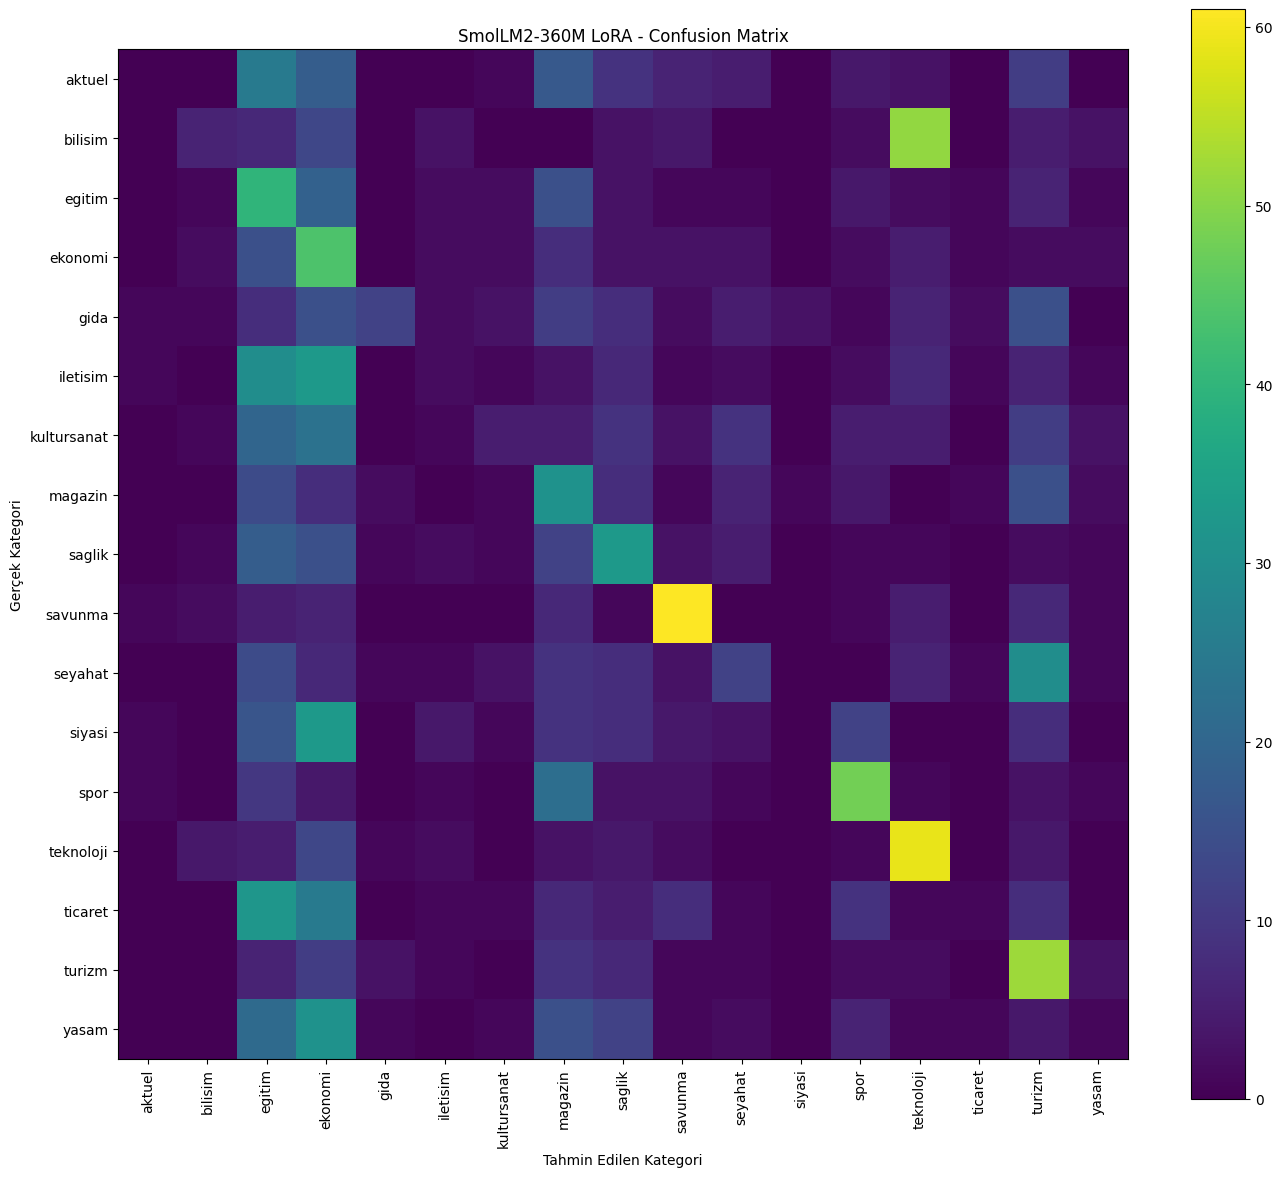

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("SmolLM2-360M LoRA - Confusion Matrix")
plt.xticks(np.arange(len(label_names)), label_names, rotation=90)
plt.yticks(np.arange(len(label_names)), label_names)
plt.colorbar()
plt.xlabel("Tahmin Edilen Kategori")
plt.ylabel("Gerçek Kategori")
plt.tight_layout()
plt.show()

In [146]:
confusions = []

for i, true_label in enumerate(label_names):
    for j, pred_label in enumerate(label_names):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "true_label": true_label,
                "pred_label": pred_label,
                "count": cm[i, j]
            })

confusions_df = pd.DataFrame(confusions).sort_values("count", ascending=False)

confusions_df.head(20)

,true_label,pred_label,count
16,bilisim,teknoloji,51
62,iletisim,ekonomi,33
134,siyasi,ekonomi,33
164,ticaret,egitim,32
187,yasam,ekonomi,31
61,iletisim,egitim,30
130,seyahat,turizm,30
0,aktuel,egitim,25
165,ticaret,ekonomi,25
75,kultursanat,ekonomi,23


In [147]:
confusions_df.to_csv(
    OUTPUT_DIR / "top_confusions.csv",
    index=False,
    encoding="utf-8"
)

print("En çok karışan kategoriler kaydedildi.")

En çok karışan kategoriler kaydedildi.


In [148]:
error_df = results_df[results_df["true_label"] != results_df["pred_label"]].copy()

print("Yanlış tahmin sayısı:", len(error_df))

error_df.head(10)

Yanlış tahmin sayısı: 1293


,true_label,pred_label,raw_output,title,content
0,ticaret,ekonomi,ekonomi,DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK,Dünya Mevtana diyarı nda buluşacak Türk ve İsl...
1,bilisim,teknoloji,teknoloji,AVERMEDİA LGP LİTE,AVerMedia LGP Lite ;raşanlar ve oyuncular HSC ...
2,bilisim,yasam,yasam,FERRARİS İVME SENSÖRÜ,ACC 93 . ACC 94 Ferraris İvme Sensörü ? ürün v...
4,teknoloji,ekonomi,ekonomi,FERRİTİK BİR ÇELİKTE KOROZYON İNCELEMELERİ,Ferritik Bir Çelikte Korozyon İncelemeleri İ E...
7,ekonomi,seyahat,seyahat,DÜNYANIN EN HIZLI BÜYÜYEN 3. ŞEHRİ,Dünyanın en hızlı büyüyen 3. şeh mim İH? Globa...
8,spor,ekonomi,ekonomi,SEDA PARS,mm aü. iiiiiiiiiiiyıaıg 25 İSİSF3ILJM SONBAHAR...
9,ekonomi,unknown,ilisim,ALTINDAĞLI KADINLAR MOBİLYA USTALARINA TAŞ ÇIK...,24 farklı mahallede hizmete açılan Kadınlar Eğ...
10,yasam,ekonomi,ekonomi,ATIK METALLERİN SANATA DÖNÜŞÜM Ü,ATIK METALLERİN SANATA DÖNÜŞÜM Ü Uçak ve araba...
11,spor,egitim,egitim,BALIK VE OLTA,"Balık ve Olta Balık türleri, av malzemeleri, t..."
12,egitim,ekonomi,ekonomi,REKLAMCILAR ANADOLU'DA BULUŞTU,Reklamcılar Anadolu da buluştu ? İletişim Bili...


In [149]:
error_examples = error_df.head(5)

for idx, row in error_examples.iterrows():
    print("Gerçek:", row["true_label"])
    print("Tahmin:", row["pred_label"])
    print("Ham çıktı:", row["raw_output"])
    print("Başlık:", row["title"])
    print("İçerik:", row["content"][:500])
    print("-" * 100)

Gerçek: ticaret
Tahmin: ekonomi
Ham çıktı: ekonomi
Başlık: DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK
İçerik: Dünya Mevtana diyarı nda buluşacak Türk ve İslam dünyasının en büyük mutasavvıflarından Mevlana Celaleddin-i Rumi, 743 üncü vuslat yıl dönümünde yurt içi ve yurt dışından farklı din ve kültürden insanları 7-1 7 Aralık ta Konya da buluşturacak. ÖĞRETİLERİ ile tüm dünyada ilgi uyandıran düşünce adamı, mutasavvıf Mevlana Celaleddin-i Rumi, vefatının 743 üncü yılında düzenlenecek törenlerle anılacak. Her yıl 7-17 Aralık tarihlerinde düzenlenen Mevlana nın Vuslat Yıl Dönümü Uluslararası Anma Törenler
----------------------------------------------------------------------------------------------------
Gerçek: bilisim
Tahmin: teknoloji
Ham çıktı: teknoloji
Başlık: AVERMEDİA LGP LİTE
İçerik: AVerMedia LGP Lite ;raşanlar ve oyuncular HSC puanı Özellikler Performans FİVat GORUNTU YAKALAMA KARTI İnternet yayıncılığıyla uj için ideal bir ürün. PTEMEL BİLGİLER Fiyat: 360 TL Web:gamerzone.avermedıe 